In [53]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 점검 (없어도 노트북은 폴백으로 끝까지 진행)
# ─────────────────────────────────────────────
# 설치가 필요하면 아래 주석을 해제하세요.
!pip install beautifulsoup4 requests -q
!pip install playwright -q && playwright install chromium
!pip install plotly

In [54]:
"""
KBO 기록실 robots.txt 확인 스크립트
- 특정 URL이 크롤링 허용되는지 확인
- User-agent별 Crawl-delay 값을 자동으로 추출
"""

import urllib.robotparser

ROBOTS_URL = "https://www.koreabaseball.com/robots.txt"
TARGET_URL = "https://www.koreabaseball.com/Record/Player/HitterBasic/Basic1.aspx?sort=HRA_RT"

# 실제로 크롤링할 때 사용할 User-Agent (Playwright 요청에도 동일하게 사용)
USER_AGENT = "MyPracticeCrawler/1.0 (+study purpose)"

DEFAULT_DELAY_IF_NONE = 2.0  # robots.txt에 delay 명시가 없을 때 안전하게 쓸 기본 간격(초)


def check_robots(target_url: str, user_agent: str) -> float:
    rp = urllib.robotparser.RobotFileParser()
    rp.set_url(ROBOTS_URL)
    rp.read()

    allowed = rp.can_fetch(user_agent, target_url)
    print(f"[URL] {target_url}")
    print(f"[User-Agent] {user_agent}")
    print(f"[크롤링 허용 여부] {'허용됨 (Allowed)' if allowed else '차단됨 (Disallowed)'}")

    delay = rp.crawl_delay(user_agent)
    if delay is None:
        delay = rp.crawl_delay("*")

    if delay is None:
        print(f"[Crawl-delay] robots.txt에 명시 없음 → 기본값 {DEFAULT_DELAY_IF_NONE}초 사용 예정")
        delay = DEFAULT_DELAY_IF_NONE
    else:
        print(f"[Crawl-delay] robots.txt 명시값: {delay}초")

    if not allowed:
        raise PermissionError("이 URL은 robots.txt에 의해 크롤링이 차단되어 있습니다. 진행하지 마세요.")

    return float(delay)


if __name__ == "__main__":
    delay = check_robots(TARGET_URL, USER_AGENT)
    print(f"\n최종 적용할 요청 간격: {delay}초")

[URL] https://www.koreabaseball.com/Record/Player/HitterBasic/Basic1.aspx?sort=HRA_RT
[User-Agent] MyPracticeCrawler/1.0 (+study purpose)
[크롤링 허용 여부] 허용됨 (Allowed)
[Crawl-delay] robots.txt에 명시 없음 → 기본값 2.0초 사용 예정

최종 적용할 요청 간격: 2.0초


In [55]:
import concurrent.futures
from crawler import crawl_team_urls_sync

if __name__ == "__main__":
    urls = [
        "https://www.koreabaseball.com/Record/Team/Hitter/Basic2.aspx",
        "https://www.koreabaseball.com/Record/Team/Pitcher/Basic1.aspx",
        "https://www.koreabaseball.com/Record/TeamRank/TeamRankDaily.aspx",
    ]

    with concurrent.futures.ProcessPoolExecutor() as executor:
        future = executor.submit(crawl_team_urls_sync, urls)
        team_data = future.result()

    hitter_records, pitcher_records, rank_records = team_data
    print(f"타자 {len(hitter_records)}행 / 투수 {len(pitcher_records)}행 / 순위 {len(rank_records)}행 수집 완료")

타자 10행 / 투수 10행 / 순위 10행 수집 완료


In [56]:
import concurrent.futures
from crawler import fetch_crowd_data_sync

if __name__ == "__main__":
    crowd_url = "https://www.koreabaseball.com/Record/Crowd/GraphTeam.aspx"

    with concurrent.futures.ProcessPoolExecutor() as executor:
        future = executor.submit(fetch_crowd_data_sync, crowd_url)
        crowd_json = future.result()

    print(crowd_json)

{'result_cd': '100', 'result_msg': '성공', 'data': [{'name': '관중 현황', 'data': [1048271, 646548, 1110786, 788890, 903718, 751629, 564312, 840383, 814818, 656781]}], 'categories': '삼성,KT,LG,KIA,두산,한화,NC,롯데,SSG,키움', 'date': '2026년 07월 22일'}


In [57]:
import pandas as pd

hitter_df = pd.DataFrame(hitter_records)
pitcher_df = pd.DataFrame(pitcher_records)
rank_df = pd.DataFrame(rank_records)

teams = crowd_json["categories"].split(",")
counts = crowd_json["data"][0]["data"]
crowd_df = pd.DataFrame({"팀명": teams, "총관중수": counts})

In [58]:
print("=== 팀 타자 기록 ===")
display(hitter_df)

print("=== 팀 투수 기록 ===")
display(pitcher_df)

print("=== 팀 순위 ===")
display(rank_df)

print("=== 관중현황 ===")
display(crowd_df)

=== 팀 타자 기록 ===


,순위,팀명,AVG,BB,IBB,HBP,SO,GDP,SLG,OBP,OPS,MH,RISP,PH-BA
0,1,KT,0.281,365,6,46,667,65,0.396,0.364,0.760,88,0.297,0.301
1,2,삼성,0.277,426,13,57,614,65,0.411,0.371,0.782,90,0.286,0.290
2,3,NC,0.277,313,10,80,645,66,0.411,0.358,0.769,86,0.274,0.255
3,4,한화,0.275,346,10,50,700,60,0.426,0.354,0.780,87,0.275,0.194
4,5,두산,0.270,322,5,55,647,70,0.397,0.344,0.741,92,0.257,0.238
5,6,LG,0.270,359,13,59,654,69,0.399,0.355,0.754,90,0.272,0.250
6,7,KIA,0.268,334,13,41,715,75,0.431,0.344,0.775,92,0.278,0.213
7,8,SSG,0.260,354,9,40,697,66,0.412,0.339,0.751,92,0.268,0.284
8,9,롯데,0.259,272,13,28,672,54,0.377,0.322,0.699,89,0.263,0.241
9,10,키움,0.238,308,5,61,798,65,0.341,0.317,0.658,92,0.223,0.240


=== 팀 투수 기록 ===


,순위,팀명,ERA,G,W,L,SV,HLD,WPCT,IP,H,HR,BB,HBP,SO,R,ER,WHIP
0,1,두산,3.84,92,47,42,21,38,0.528,818 2/3,812,69,312,55,771,400,349,1.37
1,2,삼성,4.11,90,54,34,27,54,0.614,799,777,86,326,57,668,399,365,1.38
2,3,KIA,4.25,92,49,41,16,56,0.544,814 2/3,806,86,348,46,655,428,385,1.42
3,4,롯데,4.46,90,40,48,19,42,0.455,800 2/3,829,80,342,46,721,444,397,1.46
4,5,KT,4.53,88,51,35,19,45,0.593,786 1/3,861,73,279,43,669,428,396,1.45
5,6,LG,4.56,90,52,38,37,65,0.578,795 1/3,858,77,304,46,599,428,403,1.46
6,7,한화,4.61,88,41,44,13,44,0.482,785 2/3,824,76,350,63,636,458,402,1.49
7,8,NC,4.65,87,41,45,15,43,0.477,765 2/3,735,89,370,52,700,450,396,1.44
8,9,키움,5.00,93,33,58,22,45,0.363,819 2/3,897,80,342,46,699,494,455,1.51
9,10,SSG,5.85,92,33,56,12,34,0.371,806 1/3,884,101,426,63,691,576,524,1.62


=== 팀 순위 ===


,순위,팀명,경기,승,패,무,승률,게임차,최근10경기,연속,홈,방문
0,1,삼성,90,54,34,2,0.614,0,7승0무3패,1패,28-1-16,26-1-18
1,2,KT,88,51,35,2,0.593,2,7승1무2패,7승,26-1-19,25-1-16
2,3,LG,90,52,38,0,0.578,3,2승0무8패,6패,30-0-18,22-0-20
3,4,KIA,92,49,41,2,0.544,6,5승0무5패,1패,25-2-17,24-0-24
4,5,두산,92,47,42,3,0.528,7.5,7승1무2패,3승,25-1-17,22-2-25
5,6,한화,88,41,44,3,0.482,11.5,3승1무6패,1승,18-2-25,23-1-19
6,7,NC,87,41,45,1,0.477,12,5승0무5패,1승,22-0-23,19-1-22
7,8,롯데,90,40,48,2,0.455,14,5승0무5패,1패,16-0-26,24-2-22
8,9,SSG,92,33,56,3,0.371,21.5,3승0무7패,1승,15-2-26,18-1-30
9,10,키움,93,33,58,2,0.363,22.5,4승1무5패,1승,20-1-29,13-1-29


=== 관중현황 ===


,팀명,총관중수
0,삼성,1048271
1,KT,646548
2,LG,1110786
3,KIA,788890
4,두산,903718
5,한화,751629
6,NC,564312
7,롯데,840383
8,SSG,814818
9,키움,656781


In [59]:
# 홈경기수 계산: "28-1-16" -> 28+1+16 = 45
rank_df["홈경기수"] = rank_df["홈"].apply(
    lambda x: sum(int(n) for n in x.split("-"))
)

# 관중현황(crowd_df)과 팀순위(rank_df)를 팀명 기준으로 합치기
merged_df = crowd_df.merge(rank_df[["팀명", "홈경기수"]], on="팀명", how="left")

# 평균관중 계산
merged_df["평균관중"] = (merged_df["총관중수"] / merged_df["홈경기수"]).round(0)

merged_df

,팀명,총관중수,홈경기수,평균관중
0,삼성,1048271,45,23295.0
1,KT,646548,46,14055.0
2,LG,1110786,48,23141.0
3,KIA,788890,44,17929.0
4,두산,903718,43,21017.0
5,한화,751629,45,16703.0
6,NC,564312,45,12540.0
7,롯데,840383,42,20009.0
8,SSG,814818,43,18949.0
9,키움,656781,50,13136.0


In [60]:
#간단한 EDA 진행
import pandas as pd

def quick_eda(df: pd.DataFrame, name: str):
    print(f"\n{'='*50}")
    print(f"[{name}] EDA 체크")
    print(f"{'='*50}")

    # 1. 기본 정보 (shape, 타입)
    print(f"\n[shape] {df.shape}")
    print(f"\n[dtypes]\n{df.dtypes}")

    # 2. 중복 행 확인
    dup_count = df.duplicated().sum()
    print(f"\n[중복 행 개수] {dup_count}")
    if dup_count > 0:
        print(df[df.duplicated(keep=False)])

    # 3. 결측치 확인
    print(f"\n[컬럼별 결측치 개수]\n{df.isnull().sum()}")

    # 4. 공백 문자열("", " " 등) 확인 — object(문자열) 컬럼만 대상
    print(f"\n[공백/빈 문자열 확인]")
    obj_cols = df.select_dtypes(include="object").columns
    for col in obj_cols:
        blank_count = df[col].apply(lambda x: isinstance(x, str) and x.strip() == "").sum()
        if blank_count > 0:
            print(f"  - {col}: 빈 문자열 {blank_count}개")
    if all(df[col].apply(lambda x: isinstance(x, str) and x.strip() == "").sum() == 0 for col in obj_cols):
        print("  없음")

    # 5. 숫자로 변환 가능한 컬럼인데 문자열(object)로 남아있는지 확인
    print(f"\n[숫자처럼 보이는데 object 타입인 컬럼]")
    suspicious = []
    for col in obj_cols:
        sample = df[col].dropna().astype(str).str.replace(",", "").str.replace(".", "", 1)
        if sample.str.isnumeric().mean() > 0.8:  # 80% 이상이 숫자면 의심
            suspicious.append(col)
    print(suspicious if suspicious else "  없음")

    # 6. 이상치 확인 (숫자형 컬럼만, IQR 기준)
    numeric_cols = df.select_dtypes(include="number").columns
    if len(numeric_cols) > 0:
        print(f"\n[이상치 확인 (IQR 기준, 숫자형 컬럼만)]")
        for col in numeric_cols:
            q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outliers = df[(df[col] < lower) | (df[col] > upper)]
            if len(outliers) > 0:
                print(f"  - {col}: {len(outliers)}개 이상치 (범위 밖: <{lower:.2f} 또는 >{upper:.2f})")
        if not any(
            len(df[(df[c] < df[c].quantile(0.25) - 1.5*(df[c].quantile(0.75)-df[c].quantile(0.25))) |
                   (df[c] > df[c].quantile(0.75) + 1.5*(df[c].quantile(0.75)-df[c].quantile(0.25)))]) > 0
            for c in numeric_cols
        ):
            print("  없음")
    else:
        print("\n[이상치 확인] 숫자형 컬럼 없음 (전부 object라 타입 변환 먼저 필요할 수 있음)")


# 각 데이터프레임에 적용
quick_eda(hitter_df, "팀 타자기록")
quick_eda(pitcher_df, "팀 투수기록")
quick_eda(rank_df, "팀 순위")
quick_eda(crowd_df, "관중현황")
quick_eda(merged_df, "관중+홈경기수 병합")


[팀 타자기록] EDA 체크

[shape] (10, 14)

[dtypes]
순위       str
팀명       str
AVG      str
BB       str
IBB      str
HBP      str
SO       str
GDP      str
SLG      str
OBP      str
OPS      str
MH       str
RISP     str
PH-BA    str
dtype: object

[중복 행 개수] 0

[컬럼별 결측치 개수]
순위       0
팀명       0
AVG      0
BB       0
IBB      0
HBP      0
SO       0
GDP      0
SLG      0
OBP      0
OPS      0
MH       0
RISP     0
PH-BA    0
dtype: int64

[공백/빈 문자열 확인]
  없음

[숫자처럼 보이는데 object 타입인 컬럼]
['순위', 'AVG', 'BB', 'IBB', 'HBP', 'SO', 'GDP', 'SLG', 'OBP', 'OPS', 'MH', 'RISP', 'PH-BA']

[이상치 확인] 숫자형 컬럼 없음 (전부 object라 타입 변환 먼저 필요할 수 있음)

[팀 투수기록] EDA 체크

[shape] (10, 18)

[dtypes]
순위      str
팀명      str
ERA     str
G       str
W       str
L       str
SV      str
HLD     str
WPCT    str
IP      str
H       str
HR      str
BB      str
HBP     str
SO      str
R       str
ER      str
WHIP    str
dtype: object

[중복 행 개수] 0

[컬럼별 결측치 개수]
순위      0
팀명      0
ERA     0
G       0
W       0
L       0
SV      0
HLD 

C:\Users\spide\AppData\Local\Temp\ipykernel_11840\3677055425.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns
C:\Users\spide\AppData\Local\Temp\ipykernel_11840\3677055425.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide

In [61]:
# 팀 타자기록: OPS만 float로 변환
hitter_df["OPS"] = hitter_df["OPS"].astype(float)

# 팀 투수기록: ERA만 float로 변환
pitcher_df["ERA"] = pitcher_df["ERA"].astype(float)

# 팀 순위: 승률만 float로 변환
rank_df["승률"] = rank_df["승률"].astype(float)

# 변환 확인
print(hitter_df[["팀명", "OPS"]].dtypes)
print(pitcher_df[["팀명", "ERA"]].dtypes)
print(rank_df[["팀명", "승률"]].dtypes)

팀명         str
OPS    float64
dtype: object
팀명         str
ERA    float64
dtype: object
팀명        str
승률    float64
dtype: object


In [62]:
# 필요한 컬럼만 각각 추려서 팀명 기준으로 순차 병합
final_df = hitter_df[["팀명", "OPS"]].merge(
    pitcher_df[["팀명", "ERA"]], on="팀명", how="inner"
).merge(
    rank_df[["팀명", "승률"]], on="팀명", how="inner"
).merge(
    merged_df[["팀명", "총관중수", "홈경기수", "평균관중"]], on="팀명", how="inner"
)

print(f"최종 테이블 shape: {final_df.shape}")
final_df

최종 테이블 shape: (10, 7)


,팀명,OPS,ERA,승률,총관중수,홈경기수,평균관중
0,KT,0.760,4.53,0.593,646548,46,14055.0
1,삼성,0.782,4.11,0.614,1048271,45,23295.0
2,NC,0.769,4.65,0.477,564312,45,12540.0
3,한화,0.780,4.61,0.482,751629,45,16703.0
4,두산,0.741,3.84,0.528,903718,43,21017.0
5,LG,0.754,4.56,0.578,1110786,48,23141.0
6,KIA,0.775,4.25,0.544,788890,44,17929.0
7,SSG,0.751,5.85,0.371,814818,43,18949.0
8,롯데,0.699,4.46,0.455,840383,42,20009.0
9,키움,0.658,5.00,0.363,656781,50,13136.0


In [64]:
import os

os.makedirs("./docs", exist_ok=True)  # GitHub Pages가 보통 docs 폴더를 씀

# 막대+선 그래프 3개 저장
fig_ops = plot_interactive_bar_line(final_df, "OPS", ascending=False, metric_label="OPS 높은", bar_color="steelblue")
# 주의: 기존 함수는 fig.show()로 끝나서 반환을 안 함. 아래처럼 return fig 추가 필요

In [65]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_interactive_bar_line(df, metric_col, ascending, metric_label, bar_color):
    sorted_df = df.sort_values(metric_col, ascending=ascending).reset_index(drop=True)

    fig = make_subplots(specs=[[{"secondary_y": True}]])

    fig.add_trace(
        go.Bar(x=sorted_df["팀명"], y=sorted_df[metric_col], name=metric_col,
               marker_color=bar_color, opacity=0.75,
               hovertemplate="%{x}<br>" + f"{metric_col}" + ": %{y}<extra></extra>"),
        secondary_y=False
    )
    fig.add_trace(
        go.Scatter(x=sorted_df["팀명"], y=sorted_df["평균관중"], name="평균관중",
                   mode="lines+markers", line=dict(color="black", width=2.5),
                   marker=dict(size=9),
                   hovertemplate="%{x}<br>평균관중: %{y:,}명<extra></extra>"),
        secondary_y=True
    )
    fig.update_layout(
        title=f"팀 {metric_col}({metric_label} 순) vs 평균관중(선)",
        xaxis_title=f"팀 (→ {metric_label} 순 정렬)",
        template="plotly_white", width=900, height=550
    )
    fig.update_yaxes(title_text=metric_col, secondary_y=False)
    fig.update_yaxes(title_text="평균관중(명)", secondary_y=True)

    return fig  # show() 대신 fig를 반환


# HTML로 저장
fig1 = plot_interactive_bar_line(final_df, "OPS", ascending=False, metric_label="OPS 높은", bar_color="steelblue")
fig1.write_html("./docs/ops_chart.html")

fig2 = plot_interactive_bar_line(final_df, "ERA", ascending=True, metric_label="ERA 낮은", bar_color="indianred")
fig2.write_html("./docs/era_chart.html")

fig3 = plot_interactive_bar_line(final_df, "승률", ascending=False, metric_label="승률 높은", bar_color="seagreen")
fig3.write_html("./docs/wpct_chart.html")

In [66]:
import plotly.express as px

fig_scatter = px.scatter(
    final_df, x="OPS", y="ERA",
    size="평균관중", color="평균관중",
    text="팀명",
    color_continuous_scale="YlOrRd",
    hover_data={"OPS": ":.3f", "ERA": ":.2f", "평균관중": ":,", "승률": ":.3f"},
    title="팀 OPS × ERA (크기·색 = 평균관중)"
)
fig_scatter.update_traces(textposition="top center", marker=dict(line=dict(width=1, color="black")))
fig_scatter.update_yaxes(autorange="reversed", title="ERA (아래로 갈수록 투수 좋음)")
fig_scatter.update_xaxes(title="OPS (오른쪽일수록 타격 좋음)")
fig_scatter.update_layout(template="plotly_white", width=850, height=650)

fig_scatter.write_html("./docs/scatter_chart.html")

In [ ]:
import os

os.makedirs("./docs", exist_ok=True)  # GitHub Pages가 보통 docs 폴더를 씀

# 막대+선 그래프 3개 저장
fig_ops = plot_interactive_bar_line(final_df, "OPS", ascending=False, metric_label="OPS 높은", bar_color="steelblue")
# 주의: 기존 함수는 fig.show()로 끝나서 반환을 안 함. 아래처럼 return fig 추가 필요

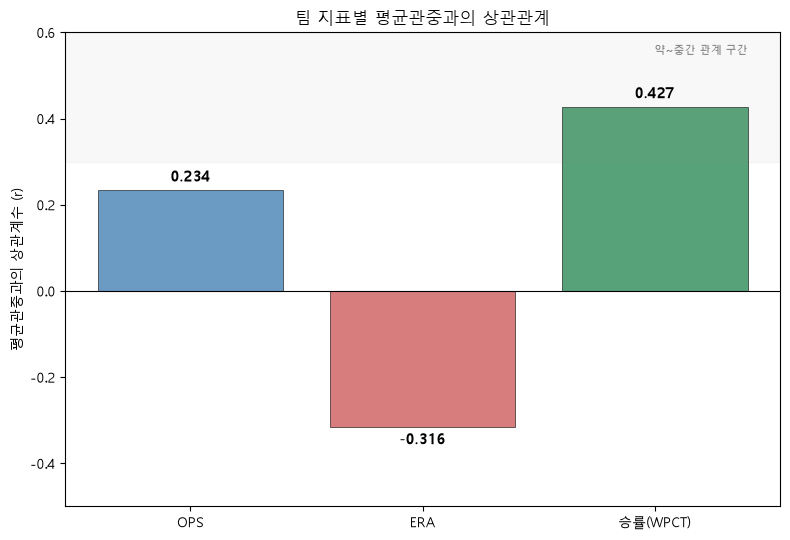

In [49]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 상관계수 계산 (ERA는 부호 반전 없이 원본 그대로 사용 -> 음수로 나옴)
corr_ops = np.corrcoef(final_df["OPS"], final_df["평균관중"])[0, 1]
corr_era = np.corrcoef(final_df["ERA"], final_df["평균관중"])[0, 1]
corr_wpct = np.corrcoef(final_df["승률"], final_df["평균관중"])[0, 1]

labels = ["OPS", "ERA", "승률(WPCT)"]
values = [corr_ops, corr_era, corr_wpct]
colors = ["steelblue", "indianred", "seagreen"]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(labels, values, color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + (0.02 if val >= 0 else -0.04),
             f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("평균관중과의 상관계수 (r)")
ax.set_title("팀 지표별 평균관중과의 상관관계")
ax.set_ylim(-0.5, 0.6)

# 참고선: 상관관계 강도 구간 표시
ax.axhspan(0.3, 0.6, color="gray", alpha=0.05)
ax.text(2.4, 0.55, "약~중간 관계 구간", fontsize=8, color="gray", ha="right")

plt.tight_layout()
plt.show()

In [48]:
import os

# 저장할 폴더 생성 (없으면 자동 생성)
save_dir = "./data"
os.makedirs(save_dir, exist_ok=True)

# 1. 원본 수집 데이터 (크롤링 직후, 가공 전)
hitter_df.to_csv(f"{save_dir}/team_hitter_raw.csv", index=False, encoding="utf-8-sig")
pitcher_df.to_csv(f"{save_dir}/team_pitcher_raw.csv", index=False, encoding="utf-8-sig")
rank_df.to_csv(f"{save_dir}/team_rank_raw.csv", index=False, encoding="utf-8-sig")
crowd_df.to_csv(f"{save_dir}/team_crowd_raw.csv", index=False, encoding="utf-8-sig")

# 2. 전처리 완료된 최종 병합 데이터
final_df.to_csv(f"{save_dir}/final_merged.csv", index=False, encoding="utf-8-sig")

print("저장 완료:")
for f in os.listdir(save_dir):
    print(f" - {save_dir}/{f}")

저장 완료:
 - ./data/final_merged.csv
 - ./data/team_crowd_raw.csv
 - ./data/team_hitter_raw.csv
 - ./data/team_pitcher_raw.csv
 - ./data/team_rank_raw.csv
